# **Coding Assignment 2 | SARSA**

### **Name** - Ravindra Mina
### **Roll** - 25AI60R02

---

# **Task 0**

<div class="alert alert-block alert-warning" style="font-size: 20px; border-radius: 5px; border-left: 5px solid #c78425;">

Run the following code snippet **without any changes**, it will extract your device OS, uniqueId, and put it into the plot!

</div>

In [9]:
pip install "gymnasium[all]"

  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 273.6 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 461.4 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 324.7 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 327.3 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 162.3 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.3/54.3 MB 257.9 kB/s eta 0:00:0000:0100:06
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 179.8 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 32

In [1]:
# code to get OS, uniqueid of your device
import getpass
import platform
import subprocess
import hashlib
import time

def get_system_unique_id():
     system = platform.system()

     try:
          if system == "Darwin":  # macOS
               uid = subprocess.check_output(
                    "ioreg -rd1 -c IOPlatformExpertDevice | awk '/IOPlatformUUID/ {print $3}'",
                    shell=True
               ).decode().strip().strip('"')

          elif system == "Linux":
               uid = open("/etc/machine-id").read().strip()

          elif system == "Windows":
               uid = subprocess.check_output(
                    "reg query HKEY_LOCAL_MACHINE\\SOFTWARE\\Microsoft\\Cryptography /v MachineGuid",
                    shell=True
               ).decode().split()[-1]

          else:
               raise Exception

     except Exception:
          uid = platform.node()  # safe fallback

     return hashlib.sha256(uid.encode()).hexdigest()


# username = getpass.getuser()
os_name = platform.system()
unique_id = get_system_unique_id()

# **Task 1**
## i. Define $\epsilon$-greedy policy function for **ACTING** in *Line no.* **48**
## ii. Define $\epsilon$-greedy policy function for **LEARNING** in *Line no.* **56**
## iii. Define the $Q$-table Update Rule for **SARSA** in *Line no.* **59**

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pickle
from datetime import datetime
import platform
from tqdm import trange


def run(episodes, epsilon=1, is_training=True, render=False, student_name='anonymous'):
    student_name = student_name.strip()
    if not student_name:
        print("Error: Name cannot be empty!")
        return

    env = gym.make('MountainCar-v0', render_mode='human' if render else None)

    # Divide position and velocity into segments
    pos_space = np.linspace(env.observation_space.low[0], env.observation_space.high[0], 20)    # Between -1.2 and 0.6
    vel_space = np.linspace(env.observation_space.low[1], env.observation_space.high[1], 20)    # Between -0.07 and 0.07

    if(is_training):
        q = np.zeros((len(pos_space), len(vel_space), env.action_space.n)) # init a 20x20x3 array
    else:
        f = open('mountain_car.pkl', 'rb')
        q = pickle.load(f)
        f.close()

    learning_rate_a = 0.9       # alpha or learning rate
    discount_factor_g = 0.9     # gamma or discount factor.

    epsilon_decay_rate = 2/episodes     # epsilon decay rate
    rng = np.random.default_rng()       # random number generator

    rewards_per_episode = np.zeros(episodes)

    for i in trange(episodes):
        state = env.reset()[0]      # Starting position, starting velocity always 0
        state_p = np.digitize(state[0], pos_space)
        state_v = np.digitize(state[1], vel_space)

        terminated = False          # True when reached goal

        rewards=0

        while(not terminated and rewards > -1000):

            ####### DEFINING THE ACTION SELECTION STRATEGY (EPSILON-GREEDY) | ACTING -------------------------------
            if is_training and rng.random()<epsilon :
              action = env.action_space.sample()

            else :
              action = np.argmax(q[state_p, state_v, :])


            new_state, reward, terminated, *_ = env.step(action)
            new_state_p = np.digitize(new_state[0], pos_space)
            new_state_v = np.digitize(new_state[1], vel_space)

            if is_training:
                ####### DEFINING THE ACTION SELECTION STRATEGY FOR THE NEW STATE (EPSILON-GREEDY) | LEARNING ----------------------
                if rng.random() < epsilon :
                  new_action = env.action_space.sample()

                else :
                  new_action = np.argmax(q[new_state_p, new_state_v, : ])


                ####### DEFINING THE Q-TABLE UPDATE RULE FOR SARSA ------------------------------------
                q[state_p, state_v, action] += learning_rate_a*(
                    reward + discount_factor_g*q[new_state_p, new_state_v, new_action] - q[state_p, state_v, action])


                action = new_action   #  (on-policy)

            state = new_state
            state_p = new_state_p
            state_v = new_state_v

            rewards+=reward

        epsilon = max(epsilon - epsilon_decay_rate, 0)

        rewards_per_episode[i] = rewards

    env.close()

    # Save Q table to file
    if is_training:
        f = open('mountain_car.pkl','wb')
        pickle.dump(q, f)
        f.close()

    mean_rewards = np.zeros(episodes)
    for t in range(episodes):
        mean_rewards[t] = np.mean(rewards_per_episode[max(0, t-100):(t+1)])

    plt.figure(figsize=(8, 6))
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    plt.title(f"Name: {student_name} \n OS: {os_name} \n Id: {unique_id} \n Time: {timestamp}")
    plt.plot(mean_rewards)
    plt.show()


# **Task 2 • Training**

## i. It will ask to **input your name** to generate the plot.
## ii. Set the ***max_episode*** to train the model properly.

100%|██████████| 15000/15000 [02:12<00:00, 112.86it/s]


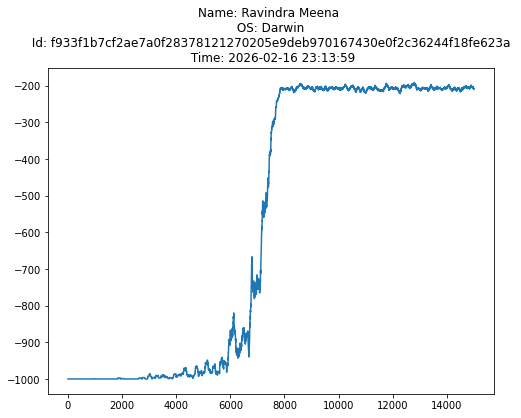

In [3]:
name = input("Your name: ")
max_episode = 15000
run(max_episode, is_training=True, render=False, student_name= name)

# **Task 3 • Testing**
## Review the Agent's performance

100%|██████████| 10/10 [01:11<00:00,  7.14s/it]


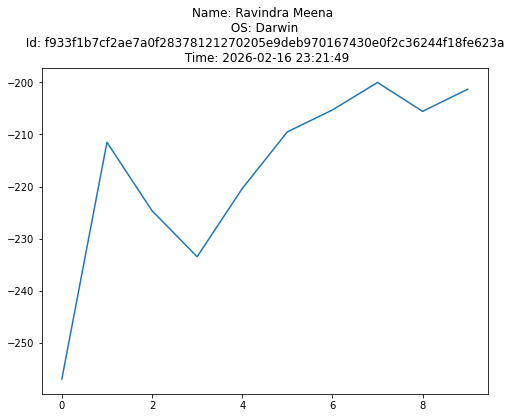

In [4]:
run(10, is_training=False, render=True, student_name= name)